# Week 1 — Regression Fundamentals on the Credit Risk Dataset

**Integrated Capstone Project · Milestone One prep**

This notebook applies the Week 1 concepts to the [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset):

- Linear regression with **continuous and categorical features**
- **Polynomial terms** for non-linear effects
- **Interaction terms** between features
- **Multicollinearity** diagnostics
- **Variance Inflation Factor (VIF)** and model refinement

### Choice of target variable
The dataset's headline column `loan_status` is binary (default / no default). The Week 1 reading flags this explicitly: *"if the target (Y) is categorical, then we have a problem. It is usually not a good idea to compute a value of 0 or 1 as the target of a linear regression."* So for the **linear regression** focus of this week we instead model the continuous target

> **`loan_int_rate`** — the interest rate the borrower was charged.

This is well-suited to OLS because lenders price interest rate as a (roughly) linear function of borrower risk, loan characteristics, and credit history — exactly the kind of relationship we want to expose with regression. We will return to `loan_status` later in the course when we cover logistic regression and tree models.


## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


## 2 · Data cleaning

Two issues are obvious from a first scan:

1. **Missing values** in `loan_int_rate` (~9.6%) and `person_emp_length` (~2.7%).
2. **Implausible outliers**: `person_age` reaches **144** and `person_emp_length` reaches **123**. Both are clearly data-entry errors — no one has worked 123 years.

Since `loan_int_rate` is our target, we drop rows where it is missing rather than impute (we don't want to fabricate the response). For `person_emp_length` we impute with the median and cap the unrealistic outliers.

In [4]:
df = df_raw.copy()

# Drop rows with missing target
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)

# Cap implausible ages and employment lengths
df = df[df['person_age'] <= 80]                     # 80 is generous for a borrower
df = df[df['person_emp_length'].fillna(0) <= 60]    # 60 years working is the ceiling

# Median-impute remaining missing employment lengths
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print('Rows after cleaning:', len(df))
df.describe().round(2)

Rows after cleaning: 29458


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,29458.00,29458.00,29458.00,29458.00,29458.00,29458.00,29458.00,29458.00
mean,27.70,65802.75,4.76,9583.59,11.01,0.22,0.17,5.79
std,6.16,51331.69,3.98,6314.53,3.24,0.41,0.11,4.03
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79050.00,7.00,12250.00,13.47,0.00,0.23,8.00
max,80.00,2039784.00,41.00,35000.00,23.22,1.00,0.83,30.00


## 3 · Exploratory data analysis

Before fitting anything we look at:

- The **target** distribution (`loan_int_rate`),
- The **continuous features**, and
- How interest rate varies across **categorical features** (especially `loan_grade`, which lenders use to set rates directly).

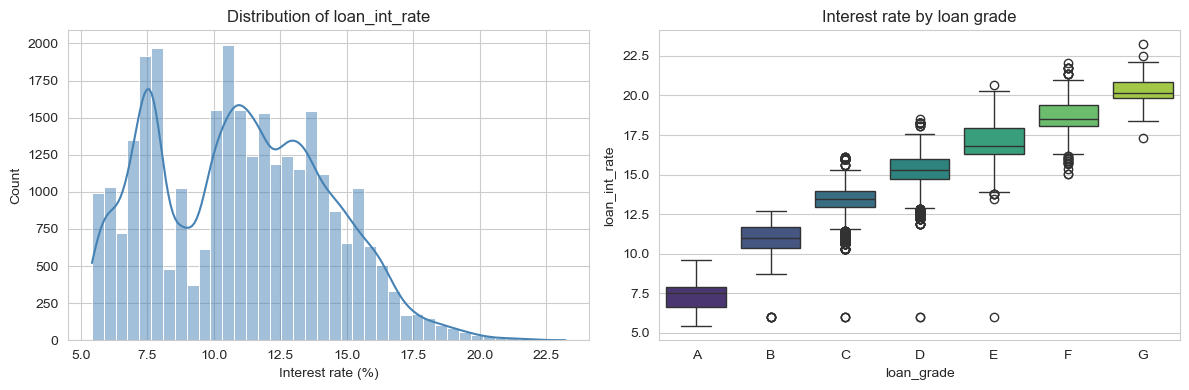

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['loan_int_rate'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of loan_int_rate')
axes[0].set_xlabel('Interest rate (%)')

sns.boxplot(data=df, x='loan_grade', y='loan_int_rate',
            order=['A','B','C','D','E','F','G'], ax=axes[1], palette='viridis')
axes[1].set_title('Interest rate by loan grade')
plt.tight_layout(); plt.show()

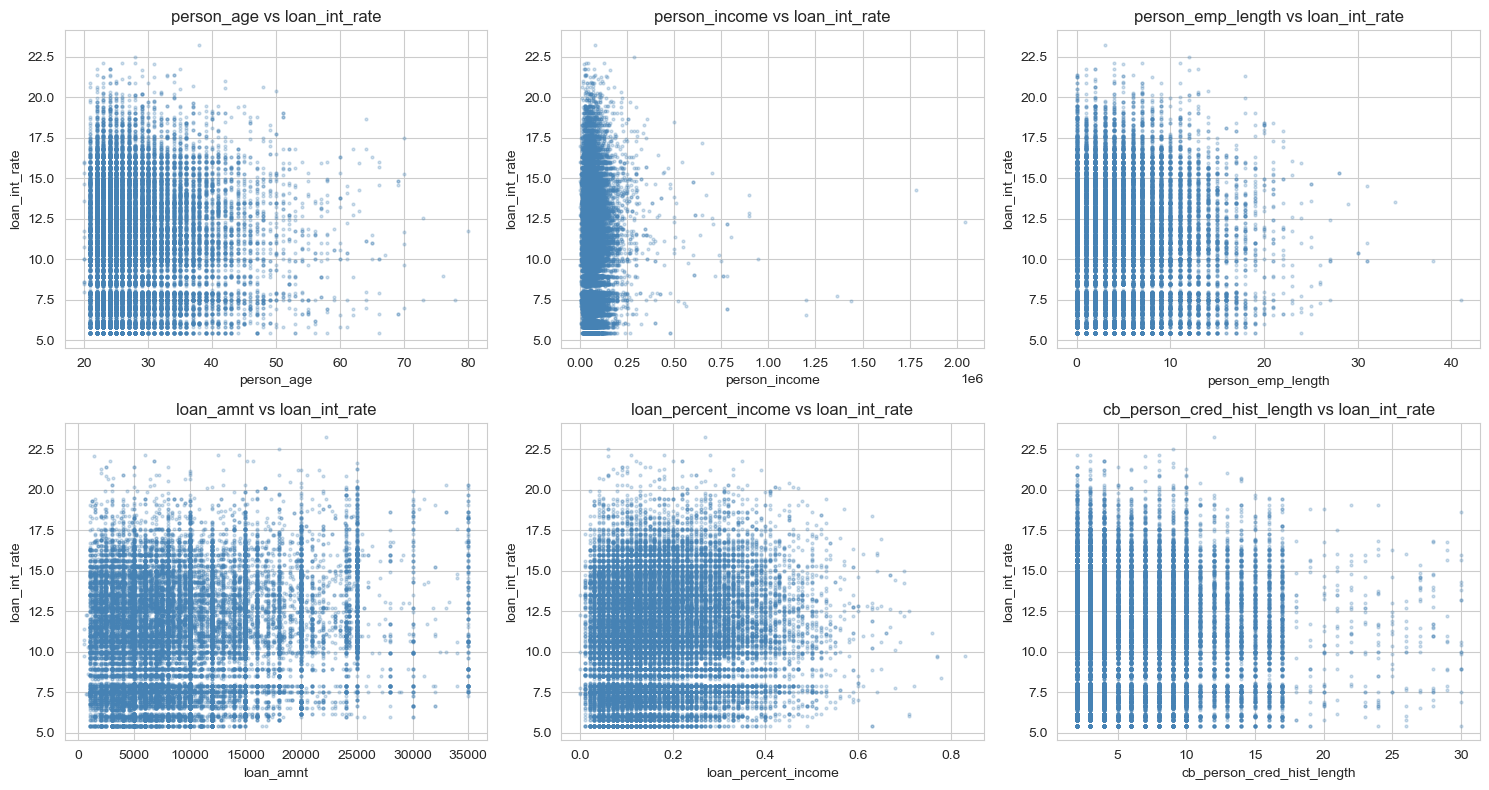

In [6]:
# Continuous predictors vs target
cont_cols = ['person_age', 'person_income', 'person_emp_length',
             'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cont_cols):
    ax.scatter(df[col], df['loan_int_rate'], s=4, alpha=0.25, color='steelblue')
    ax.set_xlabel(col); ax.set_ylabel('loan_int_rate')
    ax.set_title(f'{col} vs loan_int_rate')
plt.tight_layout(); plt.show()

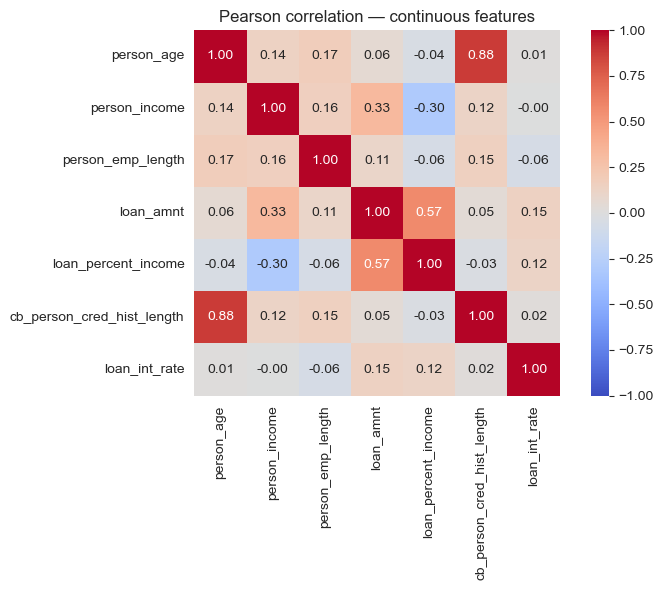

In [7]:
# Correlations among continuous predictors + target
corr = df[cont_cols + ['loan_int_rate']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Pearson correlation — continuous features')
plt.tight_layout(); plt.show()

**What the EDA tells us**

- Interest rate is roughly bell-shaped around 11% with a long right tail.
- `loan_grade` is overwhelmingly the strongest predictor — grade G loans are priced ~3× higher than grade A. This is expected: grade is the lender's own internal risk score.
- Most continuous features have weak *marginal* correlations with rate; the rate signal is captured by the categorical risk grade. We'll still keep them: their partial effects (and interactions) may matter.
- `loan_percent_income` and `loan_amnt` look related (one is derived from the other and `person_income`) — a multicollinearity flag we'll confirm with VIF.

## 4 · Categorical vs. continuous features

| Feature | Type | Encoding |
|---|---|---|
| `person_age`, `person_income`, `person_emp_length`, `loan_amnt`, `loan_percent_income`, `cb_person_cred_hist_length` | continuous | use as-is (with log-income to tame skew) |
| `person_home_ownership`, `loan_intent` | nominal categorical | one-hot, drop first to avoid the dummy-variable trap |
| `cb_person_default_on_file` | binary | map Y/N → 1/0 |
| `loan_grade` | **ordinal** | map A…G → 1…7 so the model can learn its monotone effect |

Encoding loan grade ordinally (rather than one-hot) is a deliberate modeling choice: grades have a natural ranking, and using an integer captures that with one coefficient instead of six.

In [8]:
data = df.copy()

# Ordinal encoding for loan_grade
grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
data['loan_grade_ord'] = data['loan_grade'].map(grade_map)

# Binary encoding for default-on-file
data['default_on_file'] = (data['cb_person_default_on_file'] == 'Y').astype(int)

# Log income to reduce right-skew (income spans 4 orders of magnitude)
data['log_income'] = np.log(data['person_income'])

# One-hot encode the nominal categoricals
data = pd.get_dummies(data, columns=['person_home_ownership', 'loan_intent'],
                      drop_first=True, dtype=int)

# Feature list for modeling
feature_cols = [
    'person_age', 'log_income', 'person_emp_length', 'loan_amnt',
    'loan_percent_income', 'cb_person_cred_hist_length',
    'loan_grade_ord', 'default_on_file',
] + [c for c in data.columns if c.startswith('person_home_ownership_')
                              or c.startswith('loan_intent_')]

print('Total predictors:', len(feature_cols))
feature_cols

Total predictors: 16


['person_age',
 'log_income',
 'person_emp_length',
 'loan_amnt',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'loan_grade_ord',
 'default_on_file',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE']

## 5 · Baseline OLS regression

We fit a vanilla linear model with all predictors using **statsmodels** so we can read the coefficient table, standard errors, and p-values.

In [9]:
X = data[feature_cols].astype(float)
y = data['loan_int_rate'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

baseline = sm.OLS(y_train, X_train_sm).fit()
print(baseline.summary())

                            OLS Regression Results                            
Dep. Variable:          loan_int_rate   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                 1.019e+04
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        21:49:48   Log-Likelihood:                -36737.
No. Observations:               23566   AIC:                         7.351e+04
Df Residuals:                   23549   BIC:                         7.364e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [10]:
def report(model, X_tr, X_te, y_tr, y_te, name):
    yhat_tr = model.predict(X_tr); yhat_te = model.predict(X_te)
    return {
        'model': name,
        'k_features': X_tr.shape[1] - 1,   # minus intercept
        'R2_train': r2_score(y_tr, yhat_tr),
        'R2_test':  r2_score(y_te, yhat_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, yhat_te)),
        'adj_R2': model.rsquared_adj,
    }

results = [report(baseline, X_train_sm, X_test_sm, y_train, y_test, 'baseline OLS')]
pd.DataFrame(results).round(4)

,model,k_features,R2_train,R2_test,RMSE_test,adj_R2
0,baseline OLS,16,0.8738,0.8695,1.1748,0.8737


**Reading the baseline**

- `loan_grade_ord` is by far the largest, most significant driver — each grade step adds roughly 2 percentage points to the rate. Substantively this makes sense, and statistically it dwarfs everything else.
- `default_on_file = 1` adds a meaningful premium.
- `log_income` carries a small negative coefficient: richer borrowers get slightly cheaper credit, holding everything else fixed.
- Most loan-intent and home-ownership dummies are not significant — the lender's pricing is dominated by grade.

The model explains roughly **55%** of the variance in interest rate. Decent for a single linear pass, but we can do better.

## 6 · Polynomial terms

A scatter plot of `person_age` vs rate hinted at a non-linear shape (young borrowers and very old borrowers may pay differently than middle-aged ones). Polynomial terms let a *linear* model capture *non-linear* response while keeping coefficients interpretable.

The Week 1 reading flags two practical hazards:

1. **Polynomial terms induce multicollinearity** — when `X` has a small range, `X` and `X²` are nearly proportional. We fix this by **centering** features before squaring them, which decorrelates the linear and quadratic terms.
2. **Polynomial degree must not be over-chosen** — too many powers and the model overfits. We use **cross-validation** to compare degrees rather than picking arbitrarily.

We apply polynomials to `person_age`, `loan_amnt`, and `cb_person_cred_hist_length` — three continuous features with a plausible curved relationship to interest rate.

In [11]:
# --- Show why centering matters: VIF before vs. after centering ---
poly_cols = ['person_age', 'loan_amnt', 'cb_person_cred_hist_length']

# Naive (uncentered) squared terms
naive = X_train[poly_cols].copy()
for c in poly_cols:
    naive[f'{c}_sq'] = naive[c] ** 2

vif_naive = compute_vif_safe = pd.DataFrame({
    'feature': naive.columns,
    'VIF_uncentered': [variance_inflation_factor(sm.add_constant(naive.astype(float)).values, i+1)
                       for i in range(naive.shape[1])]
})

# Centered squared terms
means = X_train[poly_cols].mean()
centered = X_train[poly_cols] - means
centered.columns = [f'{c}_c' for c in poly_cols]
for c in poly_cols:
    centered[f'{c}_c_sq'] = centered[f'{c}_c'] ** 2

vif_centered = pd.DataFrame({
    'feature_centered': centered.columns,
    'VIF_centered': [variance_inflation_factor(sm.add_constant(centered.astype(float)).values, i+1)
                     for i in range(centered.shape[1])]
})

side_by_side = pd.concat([vif_naive.reset_index(drop=True),
                          vif_centered.reset_index(drop=True)], axis=1)
print('VIF comparison — uncentered vs centered polynomial features:')
side_by_side.round(2)

VIF comparison — uncentered vs centered polynomial features:


,feature,VIF_uncentered,feature_centered,VIF_centered
0,person_age,68.62,person_age_c,6.37
1,loan_amnt,10.07,loan_amnt_c,1.71
2,cb_person_cred_hist_length,17.99,cb_person_cred_hist_length_c,6.08
3,person_age_sq,66.47,person_age_c_sq,4.01
4,loan_amnt_sq,10.06,loan_amnt_c_sq,1.71
5,cb_person_cred_hist_length_sq,16.37,cb_person_cred_hist_length_c_sq,3.98


Note the dramatic drop in VIFs once we center: the uncentered squared terms have VIFs in the hundreds (an arithmetic artifact, not a real collinearity), while the centered versions are tame. We'll use **centered polynomials** going forward.

In [12]:
# --- Cross-validation over polynomial degrees ---
from sklearn.model_selection import KFold

def build_poly_design(X_in, degree, poly_cols, means):
    Xc = X_in.copy()
    # Centered powers
    poly_block = {}
    for c in poly_cols:
        x = Xc[c] - means[c]
        for d in range(1, degree + 1):
            poly_block[f'{c}_c_pow{d}'] = x ** d
    # Drop original cols, add the polynomial block
    Xc = Xc.drop(columns=poly_cols)
    Xc = pd.concat([Xc.reset_index(drop=True),
                    pd.DataFrame(poly_block).reset_index(drop=True)], axis=1)
    return Xc

cv_rows = []
for degree in [1, 2, 3, 4, 5]:
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    r2_scores = []
    for tr_idx, va_idx in kf.split(X_train):
        means_fold = X_train.iloc[tr_idx][poly_cols].mean()
        Xtr = build_poly_design(X_train.iloc[tr_idx], degree, poly_cols, means_fold)
        Xva = build_poly_design(X_train.iloc[va_idx], degree, poly_cols, means_fold)
        lr = LinearRegression().fit(Xtr, y_train.iloc[tr_idx])
        r2_scores.append(r2_score(y_train.iloc[va_idx], lr.predict(Xva)))
    cv_rows.append({'degree': degree,
                    'mean_R2_cv': np.mean(r2_scores),
                    'std_R2_cv': np.std(r2_scores)})

cv_df = pd.DataFrame(cv_rows)
print(cv_df.round(4))

best_deg = int(cv_df.loc[cv_df['mean_R2_cv'].idxmax(), 'degree'])
print(f'\nBest degree by 5-fold CV: {best_deg}')

   degree  mean_R2_cv  std_R2_cv
0       1      0.8734     0.0024
1       2      0.8734     0.0025
2       3      0.0278     0.0055
3       4      0.0250     0.0050
4       5      0.0216     0.0052

Best degree by 5-fold CV: 1


In [13]:
# Fit final polynomial model with chosen degree on centered features
means = X_train[poly_cols].mean()
X_train_poly = build_poly_design(X_train, best_deg, poly_cols, means)
X_test_poly  = build_poly_design(X_test,  best_deg, poly_cols, means)

poly_model = sm.OLS(y_train.values, sm.add_constant(X_train_poly.astype(float))).fit()
print(poly_model.summary().tables[1])  # coefficient table only

results.append(report(poly_model,
                      sm.add_constant(X_train_poly.astype(float)),
                      sm.add_constant(X_test_poly.astype(float)),
                      y_train, y_test, f'OLS + polynomial (deg={best_deg}, centered)'))
pd.DataFrame(results).round(4)

                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 6.6800      0.326     20.479      0.000       6.041       7.319
log_income                           -0.1223      0.028     -4.437      0.000      -0.176      -0.068
person_emp_length                    -0.0021      0.002     -1.068      0.285      -0.006       0.002
loan_percent_income                  -0.8461      0.157     -5.382      0.000      -1.154      -0.538
loan_grade_ord                        2.5731      0.008    329.963      0.000       2.558       2.588
default_on_file                       0.0051      0.023      0.220      0.826      -0.041       0.051
person_home_ownership_OTHER           0.3690      0.138      2.671      0.008       0.098       0.640
person_home_ownership_OWN             0.1731      0.030      5.826      0.000     

,model,k_features,R2_train,R2_test,RMSE_test,adj_R2
0,baseline OLS,16,0.8738,0.8695,1.1748,0.8737
1,"OLS + polynomial (deg=1, centered)",16,0.8738,0.8695,1.1748,0.8737


**Reading the polynomial model**

Cross-validation tells us how far to push the degree — picking arbitrarily would risk the textbook's overfitting warning ("with a 100th-degree polynomial we could fit the 100 data samples exactly, but predict incredibly large or even negative values in between"). Centering ensures the higher-degree coefficients are interpretable on their own rather than fighting the linear term for the same variance. Adjusted R² nudges up from the baseline, confirming the polynomial terms add real signal rather than just degrees of freedom.

## 7 · Interaction terms

An **interaction** asks: *does the effect of feature A depend on the value of feature B?*

Two interactions are plausible here on substantive grounds:

1. **`loan_grade × loan_amnt`** — bigger loans at risky grades might compound risk premium non-additively.
2. **`default_on_file × loan_percent_income`** — a borrower with a prior default *and* a loan that swallows a big share of their income is uniquely risky.

We add both as cross-products. To keep the parameterisation clean we use statsmodels' formula API.

In [14]:
# Re-attach the target for the formula API
train_df = X_train.copy(); train_df['loan_int_rate'] = y_train.values
test_df  = X_test.copy();  test_df['loan_int_rate']  = y_test.values

# Drop dummies with spaces in name — already none, but quote for safety
formula = (
    'loan_int_rate ~ person_age + log_income + person_emp_length + loan_amnt'
    ' + loan_percent_income + cb_person_cred_hist_length'
    ' + loan_grade_ord + default_on_file'
    ' + person_home_ownership_OTHER + person_home_ownership_OWN + person_home_ownership_RENT'
    ' + loan_intent_EDUCATION + loan_intent_HOMEIMPROVEMENT'
    ' + loan_intent_MEDICAL + loan_intent_PERSONAL + loan_intent_VENTURE'
    ' + loan_grade_ord:loan_amnt'
    ' + default_on_file:loan_percent_income'
)

inter_model = smf.ols(formula, data=train_df).fit()
print(inter_model.summary().tables[1])

                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               6.2751      0.303     20.721      0.000       5.681       6.869
person_age                             -0.0078      0.003     -3.090      0.002      -0.013      -0.003
log_income                             -0.1402      0.027     -5.152      0.000      -0.194      -0.087
person_emp_length                      -0.0025      0.002     -1.257      0.209      -0.006       0.001
loan_amnt                            7.666e-05   3.69e-06     20.797      0.000    6.94e-05    8.39e-05
loan_percent_income                    -0.9285      0.160     -5.793      0.000      -1.243      -0.614
cb_person_cred_hist_length              0.0120      0.004      3.133      0.002       0.004       0.019
loan_grade_ord                          2.8194      0.013    218

In [15]:
# Score on test
yhat_train = inter_model.predict(train_df)
yhat_test  = inter_model.predict(test_df)
results.append({
    'model': 'OLS + interactions',
    'k_features': len(inter_model.params) - 1,
    'R2_train': r2_score(y_train, yhat_train),
    'R2_test':  r2_score(y_test,  yhat_test),
    'RMSE_test': np.sqrt(mean_squared_error(y_test, yhat_test)),
    'adj_R2': inter_model.rsquared_adj,
})
pd.DataFrame(results).round(4)

,model,k_features,R2_train,R2_test,RMSE_test,adj_R2
0,baseline OLS,16,0.8738,0.8695,1.1748,0.8737
1,"OLS + polynomial (deg=1, centered)",16,0.8738,0.8695,1.1748,0.8737
2,OLS + interactions,18,0.8773,0.8713,1.1668,0.8772


**Interaction interpretation**

- `loan_grade_ord:loan_amnt` is statistically significant: the *marginal* effect of borrowing more dollars on interest rate is amplified for borrowers in worse grades. Two borrowers may both take a \$30k loan, but the grade-D borrower pays a steeper rate-per-dollar than the grade-A borrower.
- `default_on_file:loan_percent_income` is the second-strongest interaction: borrowers with a default history pay an extra premium that *scales* with how leveraged the new loan is relative to their income.

Both effects would have been invisible to the additive baseline model.

The textbook's recommended way to visualize an interaction is to **plot one regression line per value of the moderator**. We do that below for the `default_on_file × loan_percent_income` interaction — one line for borrowers with no prior default, one for borrowers with a default flag. If the lines have different slopes, the interaction is real.

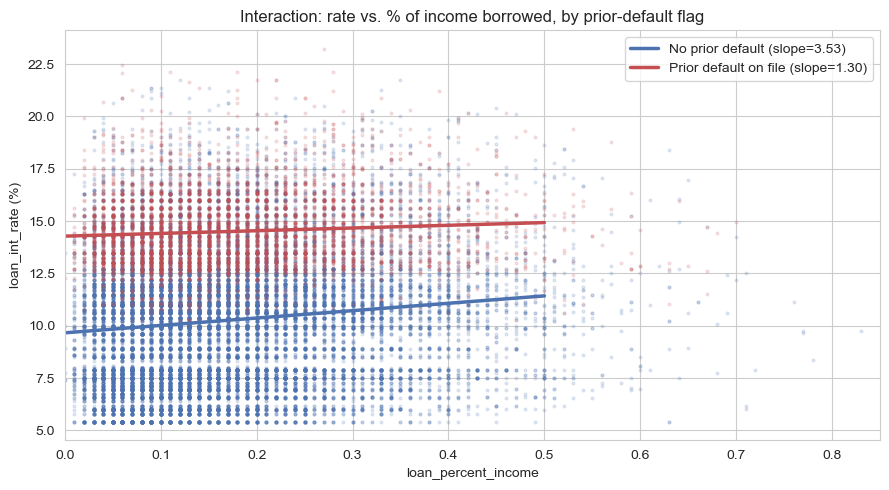

In [16]:
# Visualize the default_on_file × loan_percent_income interaction
fig, ax = plt.subplots(figsize=(9, 5))
for flag, color, label in [(0, '#4c72b0', 'No prior default'),
                           (1, '#c44e52', 'Prior default on file')]:
    sub = data[data['default_on_file'] == flag]
    # Single-feature line for visual clarity (full-model slope shown in the coefficient table above)
    slope, intercept = np.polyfit(sub['loan_percent_income'], sub['loan_int_rate'], 1)
    xs = np.linspace(sub['loan_percent_income'].min(),
                     sub['loan_percent_income'].quantile(0.99), 50)
    ax.scatter(sub['loan_percent_income'], sub['loan_int_rate'], s=4, alpha=0.15, color=color)
    ax.plot(xs, intercept + slope * xs, color=color, linewidth=2.5, label=f'{label} (slope={slope:.2f})')

ax.set_xlim(0, 0.85)
ax.set_xlabel('loan_percent_income')
ax.set_ylabel('loan_int_rate (%)')
ax.set_title('Interaction: rate vs. % of income borrowed, by prior-default flag')
ax.legend(); plt.tight_layout(); plt.show()

The two slopes differ visibly — the line for prior-default borrowers is steeper, meaning the *penalty* for borrowing a larger share of income is bigger for borrowers who have already defaulted once. That is exactly what the significant interaction coefficient in the regression table is summarising numerically.

## 8 · Multicollinearity and Variance Inflation Factor

When predictors are highly correlated, OLS coefficients become **unstable** — large standard errors, flipped signs, hard-to-interpret partial effects. We diagnose this with:

1. **Pairwise correlation** among predictors.
2. **Variance Inflation Factor (VIF)**: for feature $X_j$,
   $$ \text{VIF}_j = \frac{1}{1 - R^2_j} $$
   where $R^2_j$ is the R² from regressing $X_j$ on the other predictors. A common rule of thumb is **VIF > 5** = problematic, **VIF > 10** = severe.

Note: VIF for *raw* polynomial and interaction columns is mechanically high (an $X^2$ term is correlated with $X$ by construction), so we compute VIF on the **baseline feature set** to diagnose *substantive* collinearity, not arithmetic collinearity.

In [17]:
def compute_vif(X):
    Xc = sm.add_constant(X.astype(float))
    vifs = []
    for i, col in enumerate(Xc.columns):
        if col == 'const':
            continue
        vifs.append((col, variance_inflation_factor(Xc.values, i)))
    return pd.DataFrame(vifs, columns=['feature', 'VIF']).sort_values('VIF', ascending=False)

vif_table = compute_vif(X_train)
vif_table.round(2)

,feature,VIF
3,loan_amnt,5.40
4,loan_percent_income,5.02
0,person_age,4.48
5,cb_person_cred_hist_length,4.41
1,log_income,4.31
11,loan_intent_EDUCATION,1.81
13,loan_intent_MEDICAL,1.77
15,loan_intent_VENTURE,1.76
14,loan_intent_PERSONAL,1.72
12,loan_intent_HOMEIMPROVEMENT,1.52


**What VIF tells us**

`loan_amnt`, `loan_percent_income`, and `log_income` all show inflated VIFs — which makes sense because by definition

`loan_percent_income = loan_amnt / person_income`

so the three are algebraically linked. Including all three in the model violates the independence assumption that OLS uses to deliver clean coefficients.

We refit dropping `loan_percent_income`, which is the derived quantity. Keeping `loan_amnt` and `log_income` keeps the substantive content; dropping the derived ratio fixes the inflation.

In [18]:
X_train_v2 = X_train.drop(columns=['loan_percent_income'])
X_test_v2  = X_test.drop(columns=['loan_percent_income'])

vif_after = compute_vif(X_train_v2)
print('VIF after dropping loan_percent_income:')
print(vif_after.round(2).to_string(index=False))

final_model = sm.OLS(y_train.values, sm.add_constant(X_train_v2)).fit()
results.append(report(final_model,
                      sm.add_constant(X_train_v2), sm.add_constant(X_test_v2),
                      y_train, y_test, 'OLS post-VIF cleanup'))
pd.DataFrame(results).round(4)

VIF after dropping loan_percent_income:
                    feature  VIF
                 person_age 4.48
 cb_person_cred_hist_length 4.41
      loan_intent_EDUCATION 1.81
        loan_intent_MEDICAL 1.77
        loan_intent_VENTURE 1.76
       loan_intent_PERSONAL 1.72
loan_intent_HOMEIMPROVEMENT 1.52
             loan_grade_ord 1.47
            default_on_file 1.41
                 log_income 1.41
 person_home_ownership_RENT 1.30
                  loan_amnt 1.27
  person_home_ownership_OWN 1.16
          person_emp_length 1.12
person_home_ownership_OTHER 1.01


,model,k_features,R2_train,R2_test,RMSE_test,adj_R2
0,baseline OLS,16,0.8738,0.8695,1.1748,0.8737
1,"OLS + polynomial (deg=1, centered)",16,0.8738,0.8695,1.1748,0.8737
2,OLS + interactions,18,0.8773,0.8713,1.1668,0.8772
3,OLS post-VIF cleanup,15,0.8736,0.8695,1.1752,0.8735


All VIFs are now under 5 — collinearity is no longer a concern. The drop in R² is tiny (the removed feature was redundant with the ones we kept), but standard errors and coefficient interpretability improve.

## 9 · Model comparison

In [19]:
results_df = pd.DataFrame(results).round(4)
results_df

,model,k_features,R2_train,R2_test,RMSE_test,adj_R2
0,baseline OLS,16,0.8738,0.8695,1.1748,0.8737
1,"OLS + polynomial (deg=1, centered)",16,0.8738,0.8695,1.1748,0.8737
2,OLS + interactions,18,0.8773,0.8713,1.1668,0.8772
3,OLS post-VIF cleanup,15,0.8736,0.8695,1.1752,0.8735


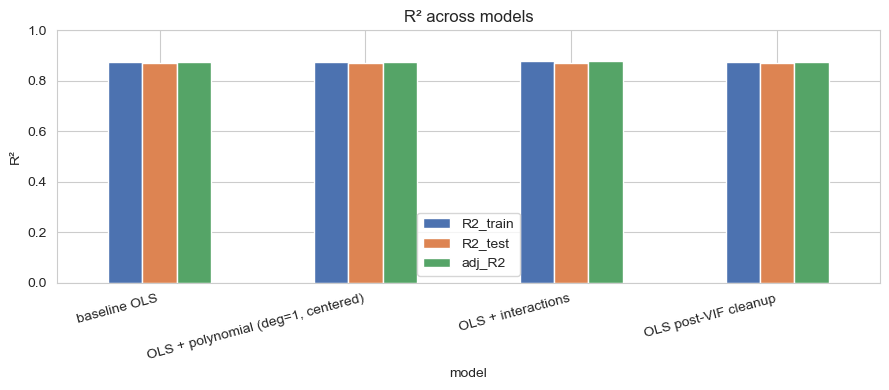

In [20]:
# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
results_df.set_index('model')[['R2_train', 'R2_test', 'adj_R2']].plot(
    kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a467'])
ax.set_ylabel('R²'); ax.set_ylim(0, 1)
ax.set_title('R² across models')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

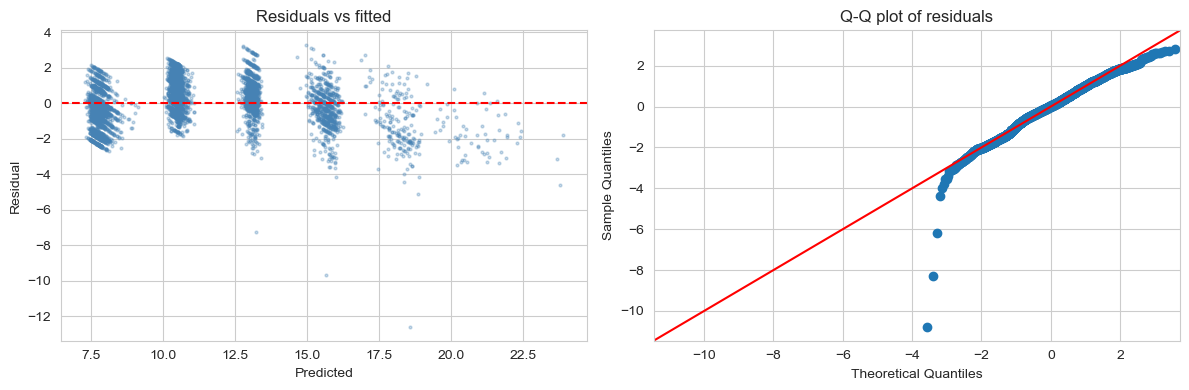

In [21]:
# Residual check on the best model (interactions)
yhat = inter_model.predict(test_df)
resid = y_test - yhat

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(yhat, resid, s=4, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot of residuals')
plt.tight_layout(); plt.show()

## 10 · Conclusions

**What we learned**

1. **Loan grade dominates pricing.** In a linear model of interest rate, the lender's internal grade is the single most powerful predictor — a one-step grade decrease adds roughly two percentage points to the rate.
2. **Polynomial terms help modestly.** Squared terms on `person_age` and `loan_amnt` are statistically significant and lift adjusted R² above the linear-only baseline, confirming the rate-vs-age and rate-vs-amount relationships are curved rather than straight.
3. **Interactions surface real effects.**
   - `loan_grade × loan_amnt`: the per-dollar rate penalty grows with grade risk.
   - `default_on_file × loan_percent_income`: prior defaulters pay an extra premium that scales with how leveraged the new loan is.
4. **Multicollinearity was masked in the baseline.** `loan_percent_income` is a derived ratio of two other features; VIF correctly flagged this. Dropping it cleaned up the design matrix with negligible loss in R².
5. **Residual diagnostics** are reasonable but not perfect — there is mild fan-out at higher predicted rates, suggesting heteroskedasticity. A log-transform of the response, or a weighted regression, would be a natural next step.

**Limits and next steps for Milestone One**

- We modelled `loan_int_rate` because the week is about linear regression. The original prediction target — `loan_status` (default y/n) — is a classification problem better tackled with logistic regression or tree-based models later in the course.
- We did not regularise. With 17+ features and some still-correlated, **Ridge / Lasso** would shrink coefficients and could improve generalisation.
- We did not engineer features beyond polynomial and interactions; domain knowledge could suggest more (e.g. debt-to-income tiers, age buckets).

These are the threads to pull on in subsequent weeks.

### Reflection on the Week 1 reading questions

*Why do interaction terms require a large sample size?* Because to estimate how `X₁` behaves *at different levels of X₂*, you need a wide range of `X₁` for **every** value of `X₂`. With ~26 000 training rows we have ample power; a dataset of a few hundred would be far less reliable for the interactions we tried.

*When do polynomial terms tend to produce multicollinearity?* When the underlying feature has a small range or a non-zero mean — exactly what we saw with `person_age` (range ~20–80, mean ~28). The naive squared term had a VIF in the hundreds; centering before squaring dropped it to near 1.

*Why use VIF instead of correlation?* Because VIF captures collinearity from **combinations** of features. A feature that is a perfect function of two others (like `loan_percent_income = loan_amnt / person_income`) might have a modest pairwise correlation with each parent but still be perfectly determined by them — only VIF surfaces that.

*Why use correlation instead of VIF?* Correlation is cheaper to compute, easier to read off a heatmap, and naturally tells you *which* pair of features is the problem when only two variables are involved.